## Tests de dependencia entre variables


Utilizamos este tipo de análisis para ver cómo son las relaciones de las variables entre nuestros datos, dos a dos. Los objetivos de este análisis son:
1. **Tipicamente miramos la relación con el target**: ver qué tipo de relación hay entre cada feature con el target, donde el target es una variable de interés especial.
2. **Descartar u obviar algunas features en nuestro análisis**: comprobar si hay dos variables muy poco relacionadas. Si estamos buscando factores de influencia de ciertas variables con respecto a un target, por ejemplo factores que influyen en los beneficios de una empresa, y encontramos una relación débil entre ciertas features y el target, entonces probablemente podremos descartar esas features de nuestro análisis.

Podemos llevar a cabo dos tipos de anális, uno mediante visualizaciones, y otro con tests y medidas estadísticas. Las visualizaciones serían el método más artesanal de ver esas relaciones entre los datos, mientras que con las medidas estadísticas puedo establecer un criterio algo más automatizado.

#### ¿Qué medidas estadísticas puedo utilizar?
La respuesta a esta pregunta depende de la naturaleza de nuestras variables y de lo que queramos medir exactamente. 



En este Anexo veremos el coeficiente 
* $\rho$ de Pearson:
    * Variables numéricas
    * Dependencia lineal
* Phi-k
    * Todo tipo de variables
    * Captura dependencias no-lineales
* Crammer-s V
    * Variables categóricas únicamente.
    * Cualquier número de categorías por variable.
* Mutual Information 
    * Cualquier combinación de tipo de variables.
    * Captura dependencias no lineales.

__

* Varianza como indicador de si esa variable puede tener influencia en otras (este último caso es sólo por completar los apuntes, en la práctica no se usa para medir dependencias, pero no está de más conocer sus fundamentos.)
    * Univariante
    * Numérica o categórica

## $\rho$ de Pearson para dos variables numéricas

Lo habitual es utilizar el coeficiente de Pearson (lo que te da una matriz de correlación) para cada dos variables, ya que es un valor normalizado entre [-1, 1]. Si el valor está en torno a 0, las dos variables tienen muy poca correlación lineal, y cuanto más cercano a 1 o -1 mejor será su correlación lineal directa o inversa respectivamente. A partir de +/- 0.6 o 0.7 suele ser una buena correlación. No obstante un coeficiente de pearson alto [no siempre asegura una buena relación entre los datos](https://www.tylervigen.com/spurious-correlations)



La ecuación es la siguiente:

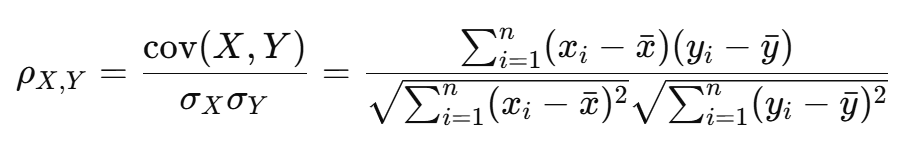

Pero nosotros no necesitamos conocer los pormenores para utilizar este coeficiente de forma acertada.

In [ ]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris


warnings.filterwarnings("ignore")


boston_df = pd.read_csv("./data/boston_house_prices.csv")

In [14]:
boston_df.corr().round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.00,-0.20,0.41,-0.06,0.42,-0.22,0.35,-0.38,0.63,0.58,0.29,-0.39,0.46,-0.39
ZN,-0.20,1.00,-0.53,-0.04,-0.52,0.31,-0.57,0.66,-0.31,-0.31,-0.39,0.18,-0.41,0.36
INDUS,0.41,-0.53,1.00,0.06,0.76,-0.39,0.64,-0.71,0.60,0.72,0.38,-0.36,0.60,-0.48
CHAS,-0.06,-0.04,0.06,1.00,0.09,0.09,0.09,-0.10,-0.01,-0.04,-0.12,0.05,-0.05,0.18
NOX,0.42,-0.52,0.76,0.09,1.00,-0.30,0.73,-0.77,0.61,0.67,0.19,-0.38,0.59,-0.43
RM,-0.22,0.31,-0.39,0.09,-0.30,1.00,-0.24,0.21,-0.21,-0.29,-0.36,0.13,-0.61,0.70
AGE,0.35,-0.57,0.64,0.09,0.73,-0.24,1.00,-0.75,0.46,0.51,0.26,-0.27,0.60,-0.38
DIS,-0.38,0.66,-0.71,-0.10,-0.77,0.21,-0.75,1.00,-0.49,-0.53,-0.23,0.29,-0.50,0.25
RAD,0.63,-0.31,0.60,-0.01,0.61,-0.21,0.46,-0.49,1.00,0.91,0.46,-0.44,0.49,-0.38
TAX,0.58,-0.31,0.72,-0.04,0.67,-0.29,0.51,-0.53,0.91,1.00,0.46,-0.44,0.54,-0.47


Fijándonos sólo en las relaciones de cada variable con el target MEDV.

In [15]:
boston_df.corr()['MEDV'].sort_values()

LSTAT     -0.737663
PTRATIO   -0.507787
INDUS     -0.483725
TAX       -0.468536
NOX       -0.427321
CRIM      -0.388305
RAD       -0.381626
AGE       -0.376955
CHAS       0.175260
DIS        0.249929
B          0.333461
ZN         0.360445
RM         0.695360
MEDV       1.000000
Name: MEDV, dtype: float64

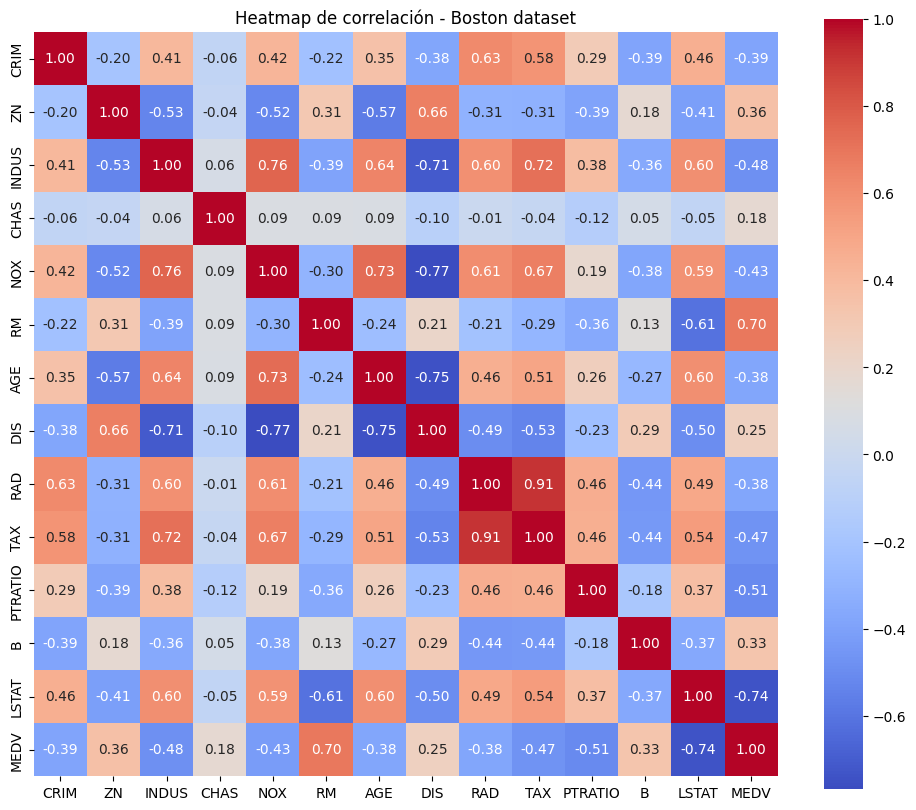

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular matriz de correlación
corr_matrix = boston_df.corr()

# Crear heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap de correlación - Boston dataset")
plt.show()

### Phi-k

Cuando queremos ver relaciones entre variables categóricas. En este caso ya no es tan útil el coeficiente de pearson. **Para detectar este tipo de relaciones recomiendo utilizar el coeficiente de Phi-k o Cramér's V**. En la [documentación de pandas profiling](https://github.com/pandas-profiling/pandas-profiling) tienes algunos ejemplos.

In [5]:
#!pip install phik

Una Phi-k matrix (o matriz de Phi-k) es una herramienta para calcular y visualizar las dependencias entre variables en un conjunto de datos. 

A diferencia de otras medidas como el coeficiente de correlación de Pearson, que está diseñado para variables numéricas, Phi-k es una forma más generalizada de analizar relaciones entre variables, ya que soporta las tres combinaciones, numérica con numérica, numérica con categórica y categórica con categórica. 

Al contrario que el coeficiente $\rho$, detecta relaciones no lineales entre variables y corrige problemas de dispersión de los datos y ruido estadístico. 

El coeficiente Phi-k está acotado entre 0 y 1. Para 0 no hay relación y un 1 nos indica que las variables son linealmente dependientes. Además es robusta frente a desequilibrios en los datos.

interval columns not set, guessing: ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']


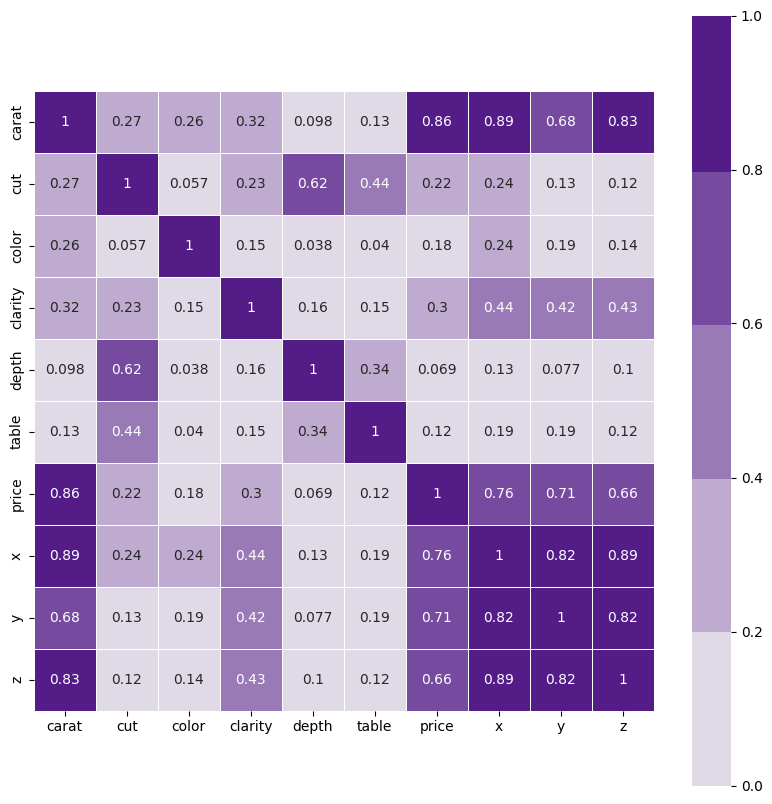

In [6]:
import phik
diamonds_df = sns.load_dataset('diamonds')
phik_matrix = diamonds_df.phik_matrix()

plt.figure(figsize=(10,10))
sns.heatmap(phik_matrix,
            vmin=0,
            vmax=1,
            center=0,
            cmap=sns.diverging_palette(145, 280, s=85, l=25, n=10),
            square=True,
            annot=True,
            linewidths=.5);

## Crammer's V

Desde un punto de vista docente, Cramér’s V es una medida de asociación entre variables categóricas, basada en el test de independencia $\chi^2$. Es útil para cuantificar cuánto dependen dos variables entre sí sin importar cuántas categorías tengan.

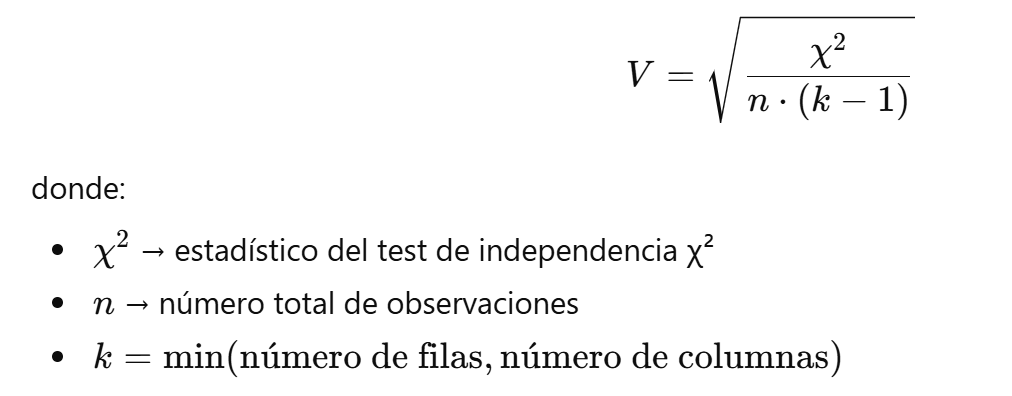
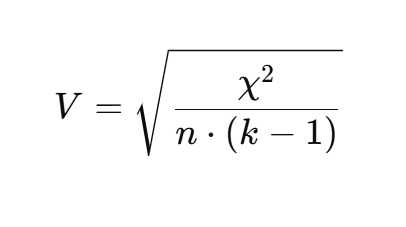

Cramér’s V = fuerza de asociación entre dos variables categóricas

Se basa en χ², que compara lo que observamos con lo que esperaríamos si fueran independientes.

Cuanto más se alejan los valores observados de los esperados, mayor V

* Un coeficiente entre 0 y 0.1 indica una relación muy débil.
* Un coeficiente entre 0.1 y 0.3 indica una relación débil. 
* Un coeficiente entre 0.3 y 0.5 indica una relación moderada.
* Un coeficiente mayor que 0.5 indica una relación fuerte.  
* El máximo es 1.0 para variables completamente dependientes.

In [7]:
titanic_df = sns.load_dataset('titanic')

In [8]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris


warnings.filterwarnings("ignore")

import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):

    contingency = pd.crosstab(x, y)

    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))



titanic_df = sns.load_dataset('titanic')

import itertools

cats = ["survived","sex","class","embarked","who","alone"]

results = pd.DataFrame(index=cats, columns=cats)

for v1, v2 in itertools.product(cats, cats):
    results.loc[v1, v2] = cramers_v(titanic_df[v1], titanic_df[v2])

results = results.astype(float)


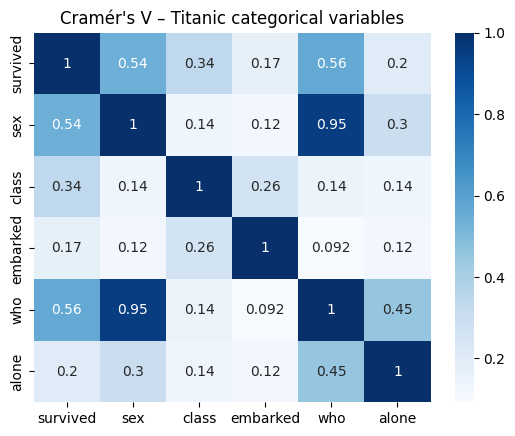

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(results, annot=True, cmap="Blues")
plt.title("Cramér's V – Titanic categorical variables")
plt.show()

### Mutual information

Desde un punto de vista docente, la Mutual Information (MI) es una medida muy útil para explicar la dependencia estadística entre variables sin asumir relaciones lineales. Es especialmente valiosa para contrastarla con la correlación. 

No es necesario saber la ecuación de la información mutua para utilizar esta medida de forma adecuada. En cualquier caso, ahí tenemos la ecuación para dos variables X e Y, que pueden ser numéricas o categóricas o mezcla.


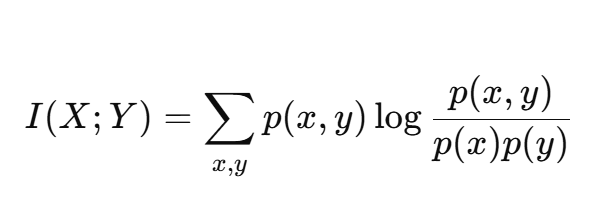

La Mutual Information mide cuánta información sobre una variable Y se obtiene al observar X.

* Si X y Y son independientes → MI = 0
* Si existe cualquier tipo de dependencia (lineal o no lineal) → MI > 0

In [10]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

# Codificar variables categóricas
df_encoded = diamonds_df.copy()
for col in ['cut','color','clarity']:
    df_encoded[col] = LabelEncoder().fit_transform(diamonds_df[col])

X = df_encoded[['carat','cut','color','clarity']]
y = df_encoded['price']

# Calcular MI
mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print("Mutual Information para price con carat, clarity, color y cut:")
print(mi_series)

Mutual Information para price con carat, clarity, color y cut:
carat      1.964298
clarity    0.365588
color      0.284548
cut        0.103146
dtype: float64


Si lo comparamos con el coeficiente $\rho$ de Pearson, vemos que para cut y color, que son categóricas no nos captura la relación:

In [11]:
from scipy.stats import pearsonr

for col in ['carat','cut','color','clarity']:
    corr, _ = pearsonr(df_encoded[col], y)
    print(f"{col}: Pearson={corr:.2f}")

carat: Pearson=0.92
cut: Pearson=0.04
color: Pearson=0.17
clarity: Pearson=-0.07


## Univariante: Varianza

Para completar, podemos adjuntar el caso de que queramos mirar las variables una a una y no por parejas para ver si pueden ser predictivas. Pués bien, una variable con varianza baja no será un buen predictor en ningún caso (teoría de la información de Shannon). 

No se deben comparar varianzas de variables no normalizadas, sin embargo el siguiente código muestra cómo se hace sin normalizar para el titatinic_df y variables categóricas incluso codificadas ya como numéricas.

In [12]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")

var_numeric = df.var(numeric_only=True)
print(var_numeric.sort_values())

survived         0.236772
alone            0.239723
adult_male       0.239723
parch            0.649728
pclass           0.699015
sibsp            1.216043
age            211.019125
fare          2469.436846
dtype: float64


No nos dejemos enganar por el resultado anterior. Podría parecer que:

* fare → gran variabilidad (precio del ticket)

* age → dispersión moderada

* sibsp y parch → muy baja variabilidad

* etc.

Pero las variables no están normalizadas así que no se puede concluir nada y deberíamos tener en cuenta todas las variables en un test estadístico de los anteriores. 